In [6]:
import decoupler as dc
import pandas as pd
import numpy as np
from pathlib import Path
import os
import matplotlib.pyplot as plt


In [2]:
# %% Setting Paths
MAIN_DIR_NAME = "proseg_data"
MAIN_DIR = next(p for p in Path.cwd().parents if (p / MAIN_DIR_NAME).exists()) / MAIN_DIR_NAME
os.chdir(MAIN_DIR)

Load the databases

In [3]:
# hallmark = dc.op.hallmark(organism="human")
# progeny = dc.op.progeny(organism="human")
# collectri = dc.op.collectri(organism="human")

Get all the cell types

In [4]:
# get the cell types from the results
celltypes_dir = MAIN_DIR / "results/comb-full/de_ct/"
celltypes = [
    item.name
    for item in celltypes_dir.iterdir()
    if item.is_dir()
]

# set all the comparisons
comparisons = [
    "CF_vs_CTRL",
    "CF_ETI_vs_CF",
    "CF_ETI_vs_CTRL",
]

# create a folder for each comparison inside each cell type folder
for celltype in celltypes:
    for comparison in comparisons:
        outdir = celltypes_dir / celltype / comparison
        outdir.mkdir(parents=True, exist_ok=True)

In [7]:
for ct in celltypes:
    for comp in comparisons:

        de_path = celltypes_dir / ct / f"de_{comp}_{ct}.tsv"
        out_dir = celltypes_dir / ct / comp

        # read the DE file
        de = pd.read_csv(
            de_path,
            sep="\t",
            index_col=0
        )

        fig = dc.pl.volcano(
            data=de,
            x="log2Fold",
            y="P.adj",
            thr_stat=0.5,
            thr_sign=0.05,
            top=30,
            figsize=(10, 10),
            return_fig=True,
        )

        # save as PNG and SVG
        for ext in ["png", "svg"]:
            save_path = out_dir / f"volcano.{ext}"
            fig.savefig(
                save_path,
                dpi=300,
                bbox_inches="tight",
            )
            print(save_path)

        # close the figure
        plt.close(fig)

        print(f"{ct} {comp} finished")

/mnt/autofs/data/userdata/project0062/proseg_data/results/comb-full/de_ct/CD4_T/CF_vs_CTRL/volcano.png
/mnt/autofs/data/userdata/project0062/proseg_data/results/comb-full/de_ct/CD4_T/CF_vs_CTRL/volcano.svg
CD4_T CF_vs_CTRL finished
/mnt/autofs/data/userdata/project0062/proseg_data/results/comb-full/de_ct/CD4_T/CF_ETI_vs_CF/volcano.png
/mnt/autofs/data/userdata/project0062/proseg_data/results/comb-full/de_ct/CD4_T/CF_ETI_vs_CF/volcano.svg
CD4_T CF_ETI_vs_CF finished
/mnt/autofs/data/userdata/project0062/proseg_data/results/comb-full/de_ct/CD4_T/CF_ETI_vs_CTRL/volcano.png
/mnt/autofs/data/userdata/project0062/proseg_data/results/comb-full/de_ct/CD4_T/CF_ETI_vs_CTRL/volcano.svg
CD4_T CF_ETI_vs_CTRL finished
/mnt/autofs/data/userdata/project0062/proseg_data/results/comb-full/de_ct/PC_K_IgAG/CF_vs_CTRL/volcano.png
/mnt/autofs/data/userdata/project0062/proseg_data/results/comb-full/de_ct/PC_K_IgAG/CF_vs_CTRL/volcano.svg
PC_K_IgAG CF_vs_CTRL finished
/mnt/autofs/data/userdata/project0062/pros

In [6]:
print(ct)

CD4_T


In [25]:
import decoupler as dc
dc.pl.volcano?

Signature:
dc.pl.volcano(
    data: pandas.core.frame.DataFrame,
    x: str,
    y: str,
    net: pandas.core.frame.DataFrame | None = None,
    name: str | None = None,
    top: int = 5,
    thr_stat: float = 0.5,
    thr_sign: float = 0.05,
    max_stat: float | None = None,
    max_sign: float | None = None,
    color_pos: str = '#D62728',
    color_neg: str = '#1F77B4',
    color_null: str = 'gray',
    kw_scatter: dict | None = None,
    **kwargs,
) -> None | matplotlib.figure.Figure
Docstring:
Plot logFC and p-values from a long formated data-frame.

Parameters
----------
data
    DataFrame containing feature-level statistics. Feature names must be in ``df.index``.
x
    Column name of ``data`` storing the change statitsics.
y
    Column name of ``data`` storing the associated p-values.
net
    Dataframe in long format. Must include ``source`` and ``target`` columns, and optionally a ``weight`` column.
name
    Name of the source to subset ``net``.
top
    Number of top different

Load the de table

In [6]:
# load the de table
celltype = 'Club'
de_path = MAIN_DIR / f'results/comb-full/de_ct/{celltype}/de_CF_vs_CTRL_{celltype}.tsv'
de = pd.read_csv(
    de_path,
    sep='\t',
    index_col=0
)

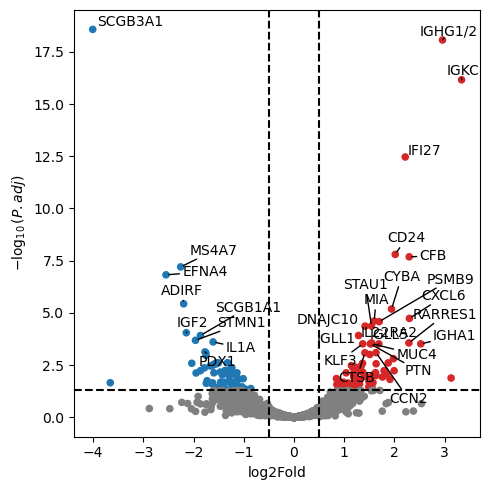

In [7]:

dc.pl.volcano(
    data=de,
    x="log2Fold",
    y="P.adj",
    thr_stat=0.5,
    thr_sign=0.05,
    top=30,
    figsize=(5, 5),
)

In [8]:
data = de[["stat"]].T.rename(index={"stat": "disease.vs.normal"})
data

ID,SCGB3A1,IGHG1/2,IGKC,IFI27,CD24,CFB,MS4A7,EFNA4,ADIRF,CYBA,...,NDUFAF7,PGD,PPARGC1B,SLC1A5,UIMC1,APH1A,IL2,SPTLC2,MCEE,ASAP2
disease.vs.normal,-9.896528,9.70847,9.207206,8.209779,6.770728,6.705766,-6.518424,-6.365555,-5.835973,5.721504,...,0.002132,-0.002937,0.001922,-0.002824,0.003582,-0.001427,0.001583,-0.001108,-0.000861,-0.000383


## Hallmark

In [9]:
# Run
hm_acts, hm_padj = dc.mt.ulm(data=data, net=hallmark)

# Filter by sign padj
msk = (hm_padj.T < 0.05).iloc[:, 0]
hm_acts = hm_acts.loc[:, msk]

hm_acts

,ALLOGRAFT_REJECTION,CHOLESTEROL_HOMEOSTASIS,EPITHELIAL_MESENCHYMAL_TRANSITION,HEME_METABOLISM,IL2_STAT5_SIGNALING,IL6_JAK_STAT3_SIGNALING,INFLAMMATORY_RESPONSE,INTERFERON_ALPHA_RESPONSE,INTERFERON_GAMMA_RESPONSE,KRAS_SIGNALING_DN,KRAS_SIGNALING_UP,OXIDATIVE_PHOSPHORYLATION,PANCREAS_BETA_CELLS,PROTEIN_SECRETION,TNFA_SIGNALING_VIA_NFKB
disease.vs.normal,-2.920848,-3.544301,-3.972796,2.499978,-4.353115,-3.472507,-5.105189,4.363804,3.739133,-5.002057,-2.76308,4.541612,-3.333219,3.243297,-4.939431


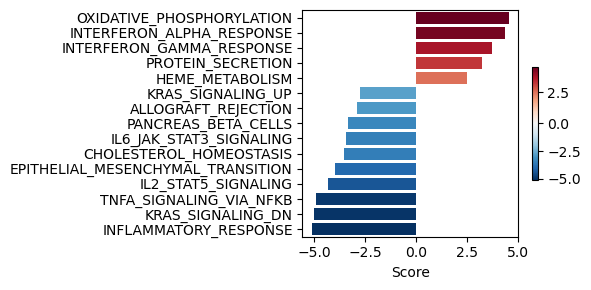

In [10]:
dc.pl.barplot(data=hm_acts, name="disease.vs.normal", figsize=(6, 3))

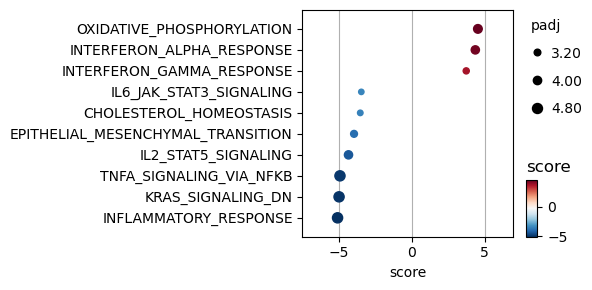

In [11]:
# Tranform to df
df = hm_acts.melt(value_name="score").merge(
    hm_padj.melt(value_name="pvalue")
    .assign(padj=lambda x: x["pvalue"].clip(2.22e-16, 1))
    .assign(padj=lambda x: np.log10(x["pvalue"]))
)
dc.pl.dotplot(df=df, x="score", y="variable", s="padj", c="score", scale=0.25, figsize=(6, 3))

## Progeny

In [12]:
# Run
pw_acts, pw_padj = dc.mt.ulm(data=data, net=progeny)

# Filter by sign padj
msk = (pw_padj.T < 0.05).iloc[:, 0]
pw_acts = pw_acts.loc[:, msk]

pw_acts

,EGFR,Estrogen,JAK-STAT,MAPK,NFkB,Trail
disease.vs.normal,-8.321004,-4.907601,5.601902,-9.175282,-2.336112,-2.387603


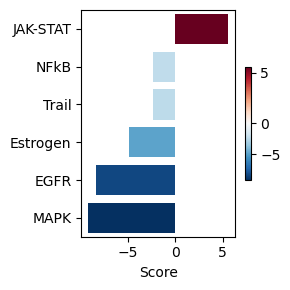

In [13]:
dc.pl.barplot(data=pw_acts, name="disease.vs.normal", figsize=(3, 3))

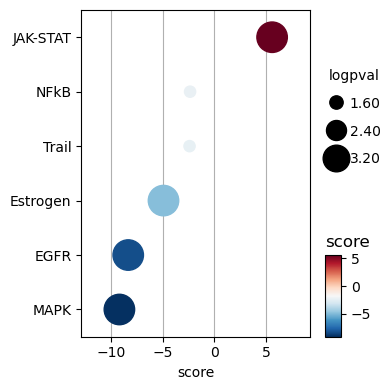

In [14]:
# Transform to df
df = pw_acts.melt(value_name="score").merge(
    pw_padj.melt(value_name="pvalue")
    .assign(logpval=lambda x: x["pvalue"].clip(2.22e-4, 1))
    .assign(logpval=lambda x: -np.log10(x["logpval"]))
)
dc.pl.dotplot(df=df, x="score", y="variable", s="logpval", c="score", scale=1, figsize=(4, 4))

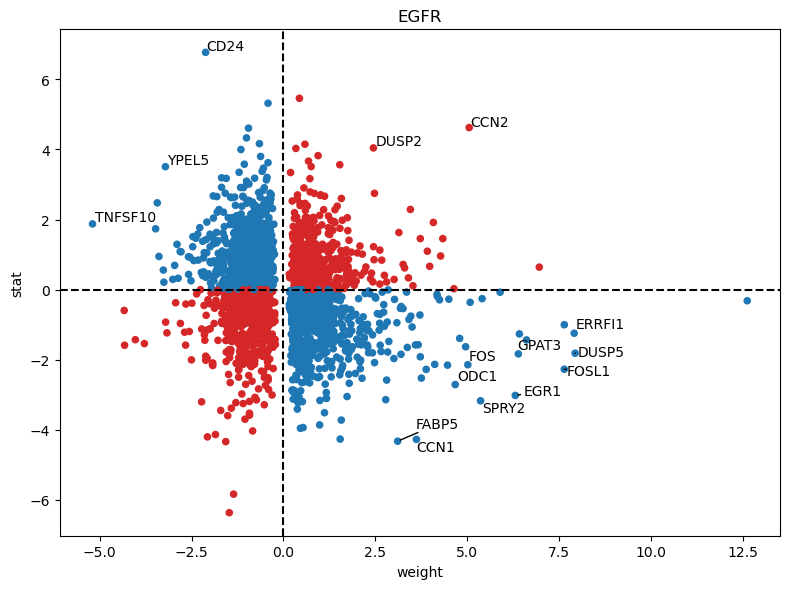

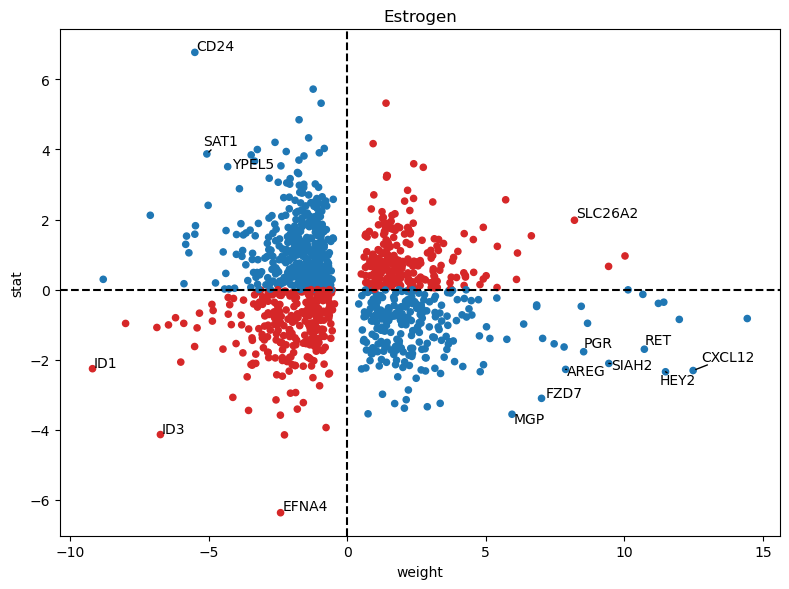

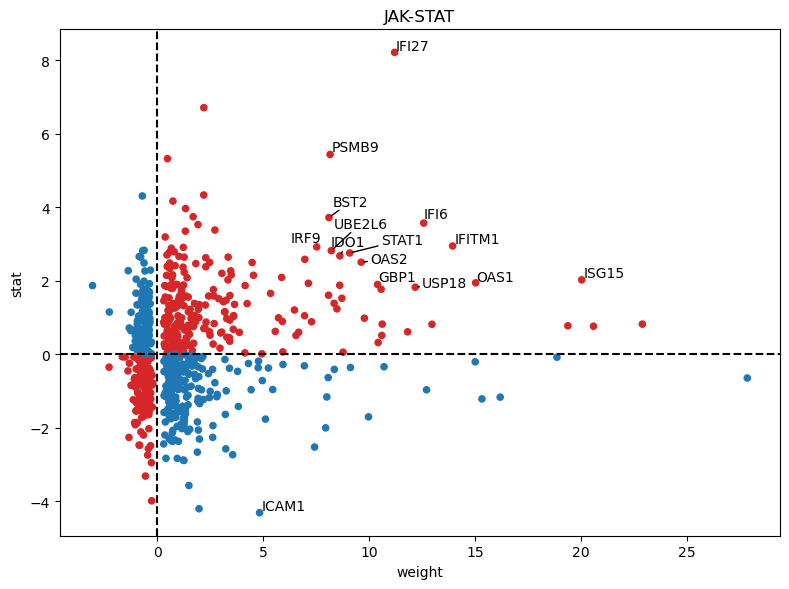

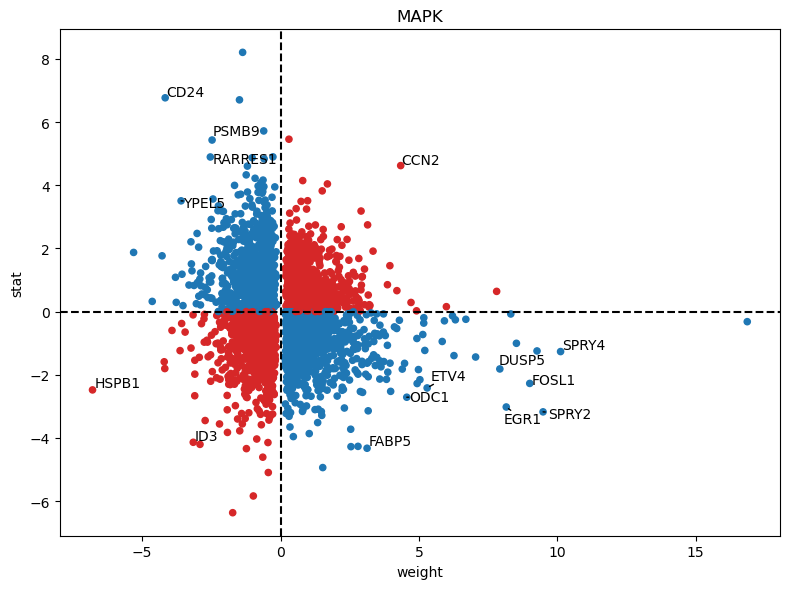

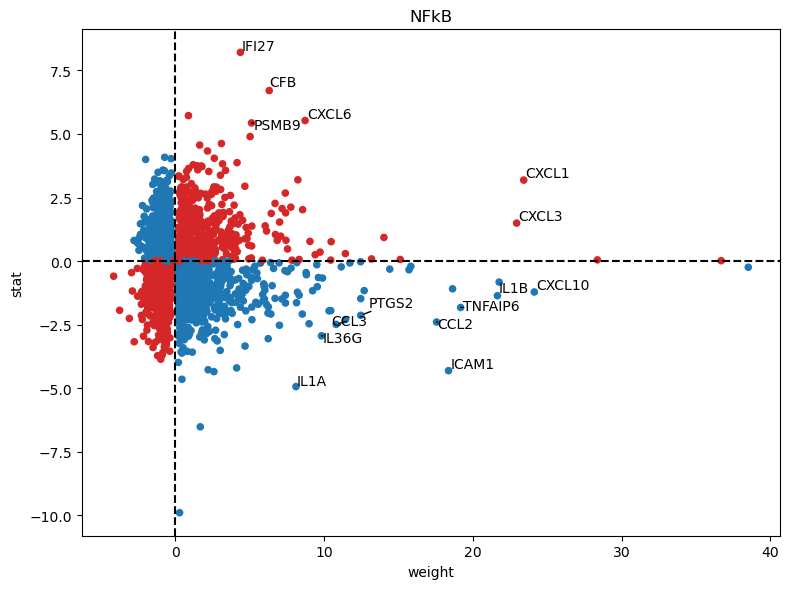

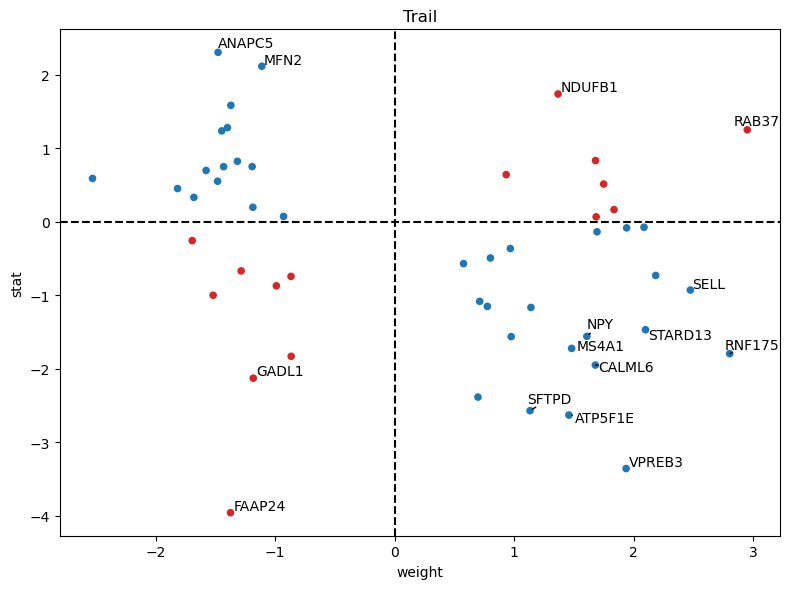

In [15]:
pathways = df['variable'].tolist()

for pw in pathways:
    dc.pl.source_targets(data=de, x="weight", y="stat", net=progeny, name=f'{pw}', top=15, figsize=(8, 6))

(+) leading edge: ['FABP5' 'CCN1' 'EMP1' 'FAAP24' 'HOPX']
(-) leading edge: ['CD24' 'STAU1' 'CTSB' 'B2M' 'GOLM1']
(+) leading edge: ['MGP' 'THBS4' 'COL21A1' 'ADRA2A' 'GADD45G']
(-) leading edge: ['CD24' 'CYBA' 'STAU1' 'KLF3' 'B2M']
(+) leading edge: ['IFI27' 'CFB' 'PSMB9' 'STAU1' 'B2M']
(-) leading edge: ['HBB' 'ADA2' 'BDH1' 'ABCA5' 'TRIM2']
(+) leading edge: ['IL1A' 'FABP5' 'CCN1' 'EMP1' 'FAAP24']
(-) leading edge: ['IFI27' 'CD24' 'CFB' 'CYBA' 'PSMB9']
(+) leading edge: ['SCGB3A1' 'MS4A7' 'IL1A' 'PDX1' 'RCAN1']
(-) leading edge: ['SELENOW' 'PHKG2' 'UCP2' 'MGMT' 'SMAP2']
(+) leading edge: ['VPREB3' 'ATP5F1E' 'SFTPD' 'VIPR2' 'CALML6']
(-) leading edge: ['FAAP24' 'GADL1' 'MPIG6B']


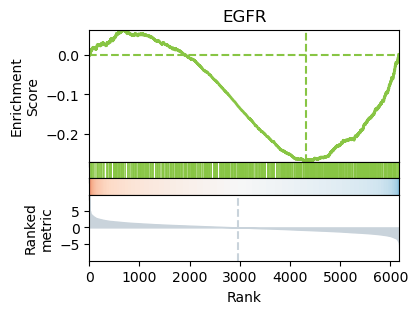

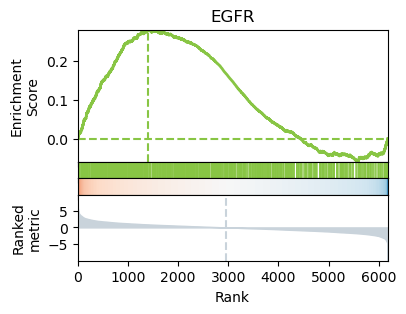

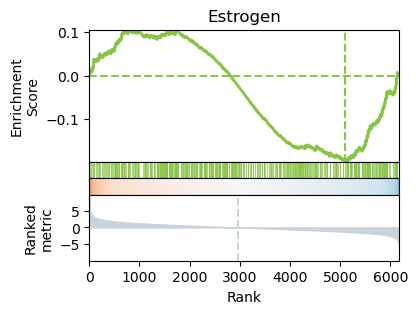

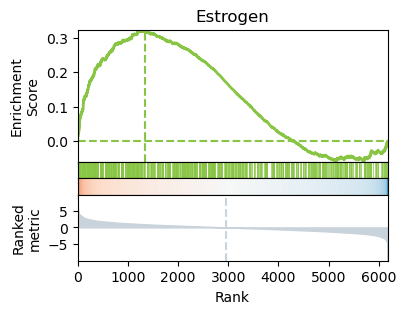

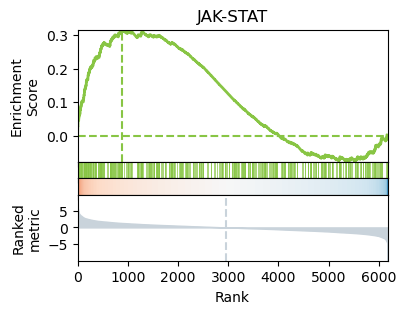

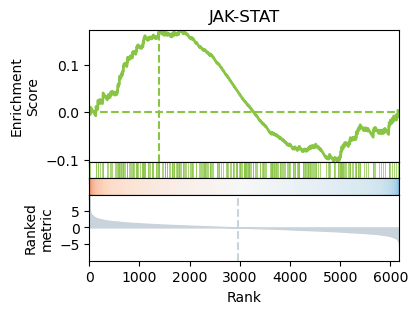

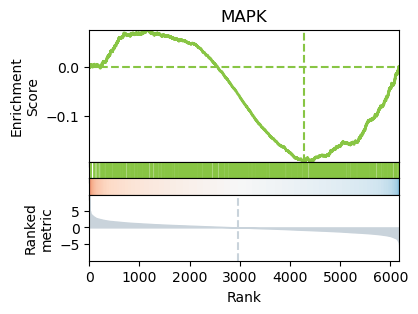

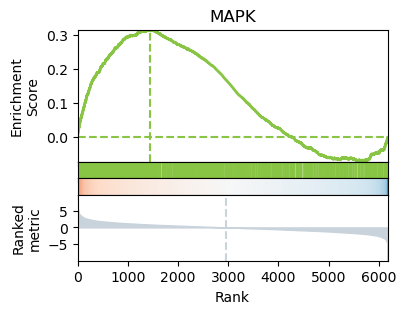

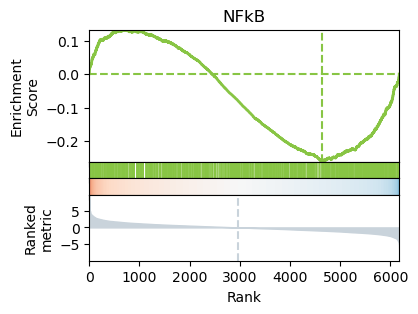

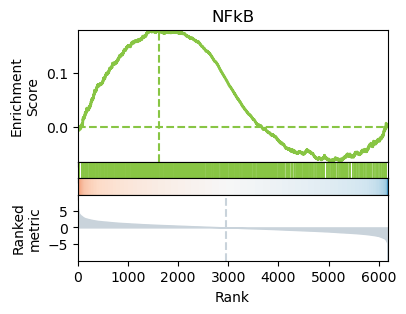

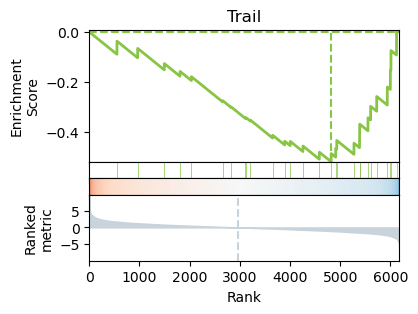

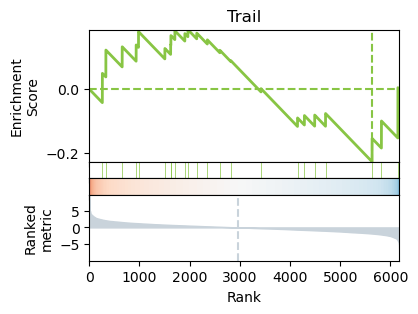

In [16]:
for pw in pathways:

    _, pos_le = dc.pl.leading_edge(
        de,
        stat="stat",
        net=progeny[progeny["weight"] > 0],
        name=pw,
    )
    print("(+) leading edge:", pos_le[:5])
    _, neg_le = dc.pl.leading_edge(
        de,
        stat="stat",
        net=progeny[progeny["weight"] < 0],
        name=pw,
    )
    print("(-) leading edge:", neg_le[:5])

## Collectri

In [17]:
# Run
tf_acts, tf_padj = dc.mt.ulm(data=data, net=collectri)

# Filter by sign padj
msk = (tf_padj.T < 0.05).iloc[:, 0]
tf_acts = tf_acts.loc[:, msk]

tf_acts

,AHR,AP1,ATF2,ATF4,BATF,BCL11A,BMAL1,CEBPA,CEBPB,CEBPG,...,SSRP1,STAT3,STAT5A,STAT6,TBX3,TCF4,TCF7L2,TTF1,ZBTB18,ZGLP1
disease.vs.normal,-3.102293,-4.985973,-2.963716,-2.911018,-3.091197,-3.361658,-2.824571,-5.085872,-5.069608,-3.362927,...,-3.389748,-4.812119,-2.957424,-3.173264,3.773078,-3.155754,-3.607404,-3.086388,3.3652,-4.053562


In [18]:
tfs = tf_acts.columns.tolist()
print(tfs)

['AHR', 'AP1', 'ATF2', 'ATF4', 'BATF', 'BCL11A', 'BMAL1', 'CEBPA', 'CEBPB', 'CEBPG', 'CIITA', 'CREB1', 'CTNNB1', 'CUX1', 'DNMT1', 'E2F1', 'EGR1', 'ESR1', 'ETV4', 'FOS', 'GATA4', 'GATA6', 'GLI3', 'HNF1A', 'HNF1B', 'HOXB7', 'HSF2', 'ID1', 'JUN', 'JUNB', 'KLF15', 'KLF5', 'LEF1', 'LYL1', 'MAF', 'NFATC1', 'NFATC4', 'NFKB', 'NFKB1', 'NFKB2', 'NR5A1', 'NR5A2', 'ONECUT1', 'OTX2', 'PAX3', 'PLAG1', 'PLAGL1', 'POU3F2', 'RARA', 'RFX5', 'RFXANK', 'RFXAP', 'RXRA', 'SMAD1', 'SMAD2', 'SMAD3', 'SMAD4', 'SMAD5', 'SP1', 'SP3', 'SPI1', 'SSRP1', 'STAT3', 'STAT5A', 'STAT6', 'TBX3', 'TCF4', 'TCF7L2', 'TTF1', 'ZBTB18', 'ZGLP1']


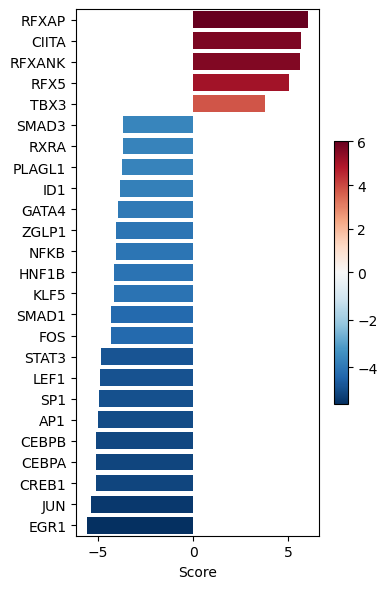

In [20]:
dc.pl.barplot(data=tf_acts, name="disease.vs.normal", top=25, figsize=(4, 6))

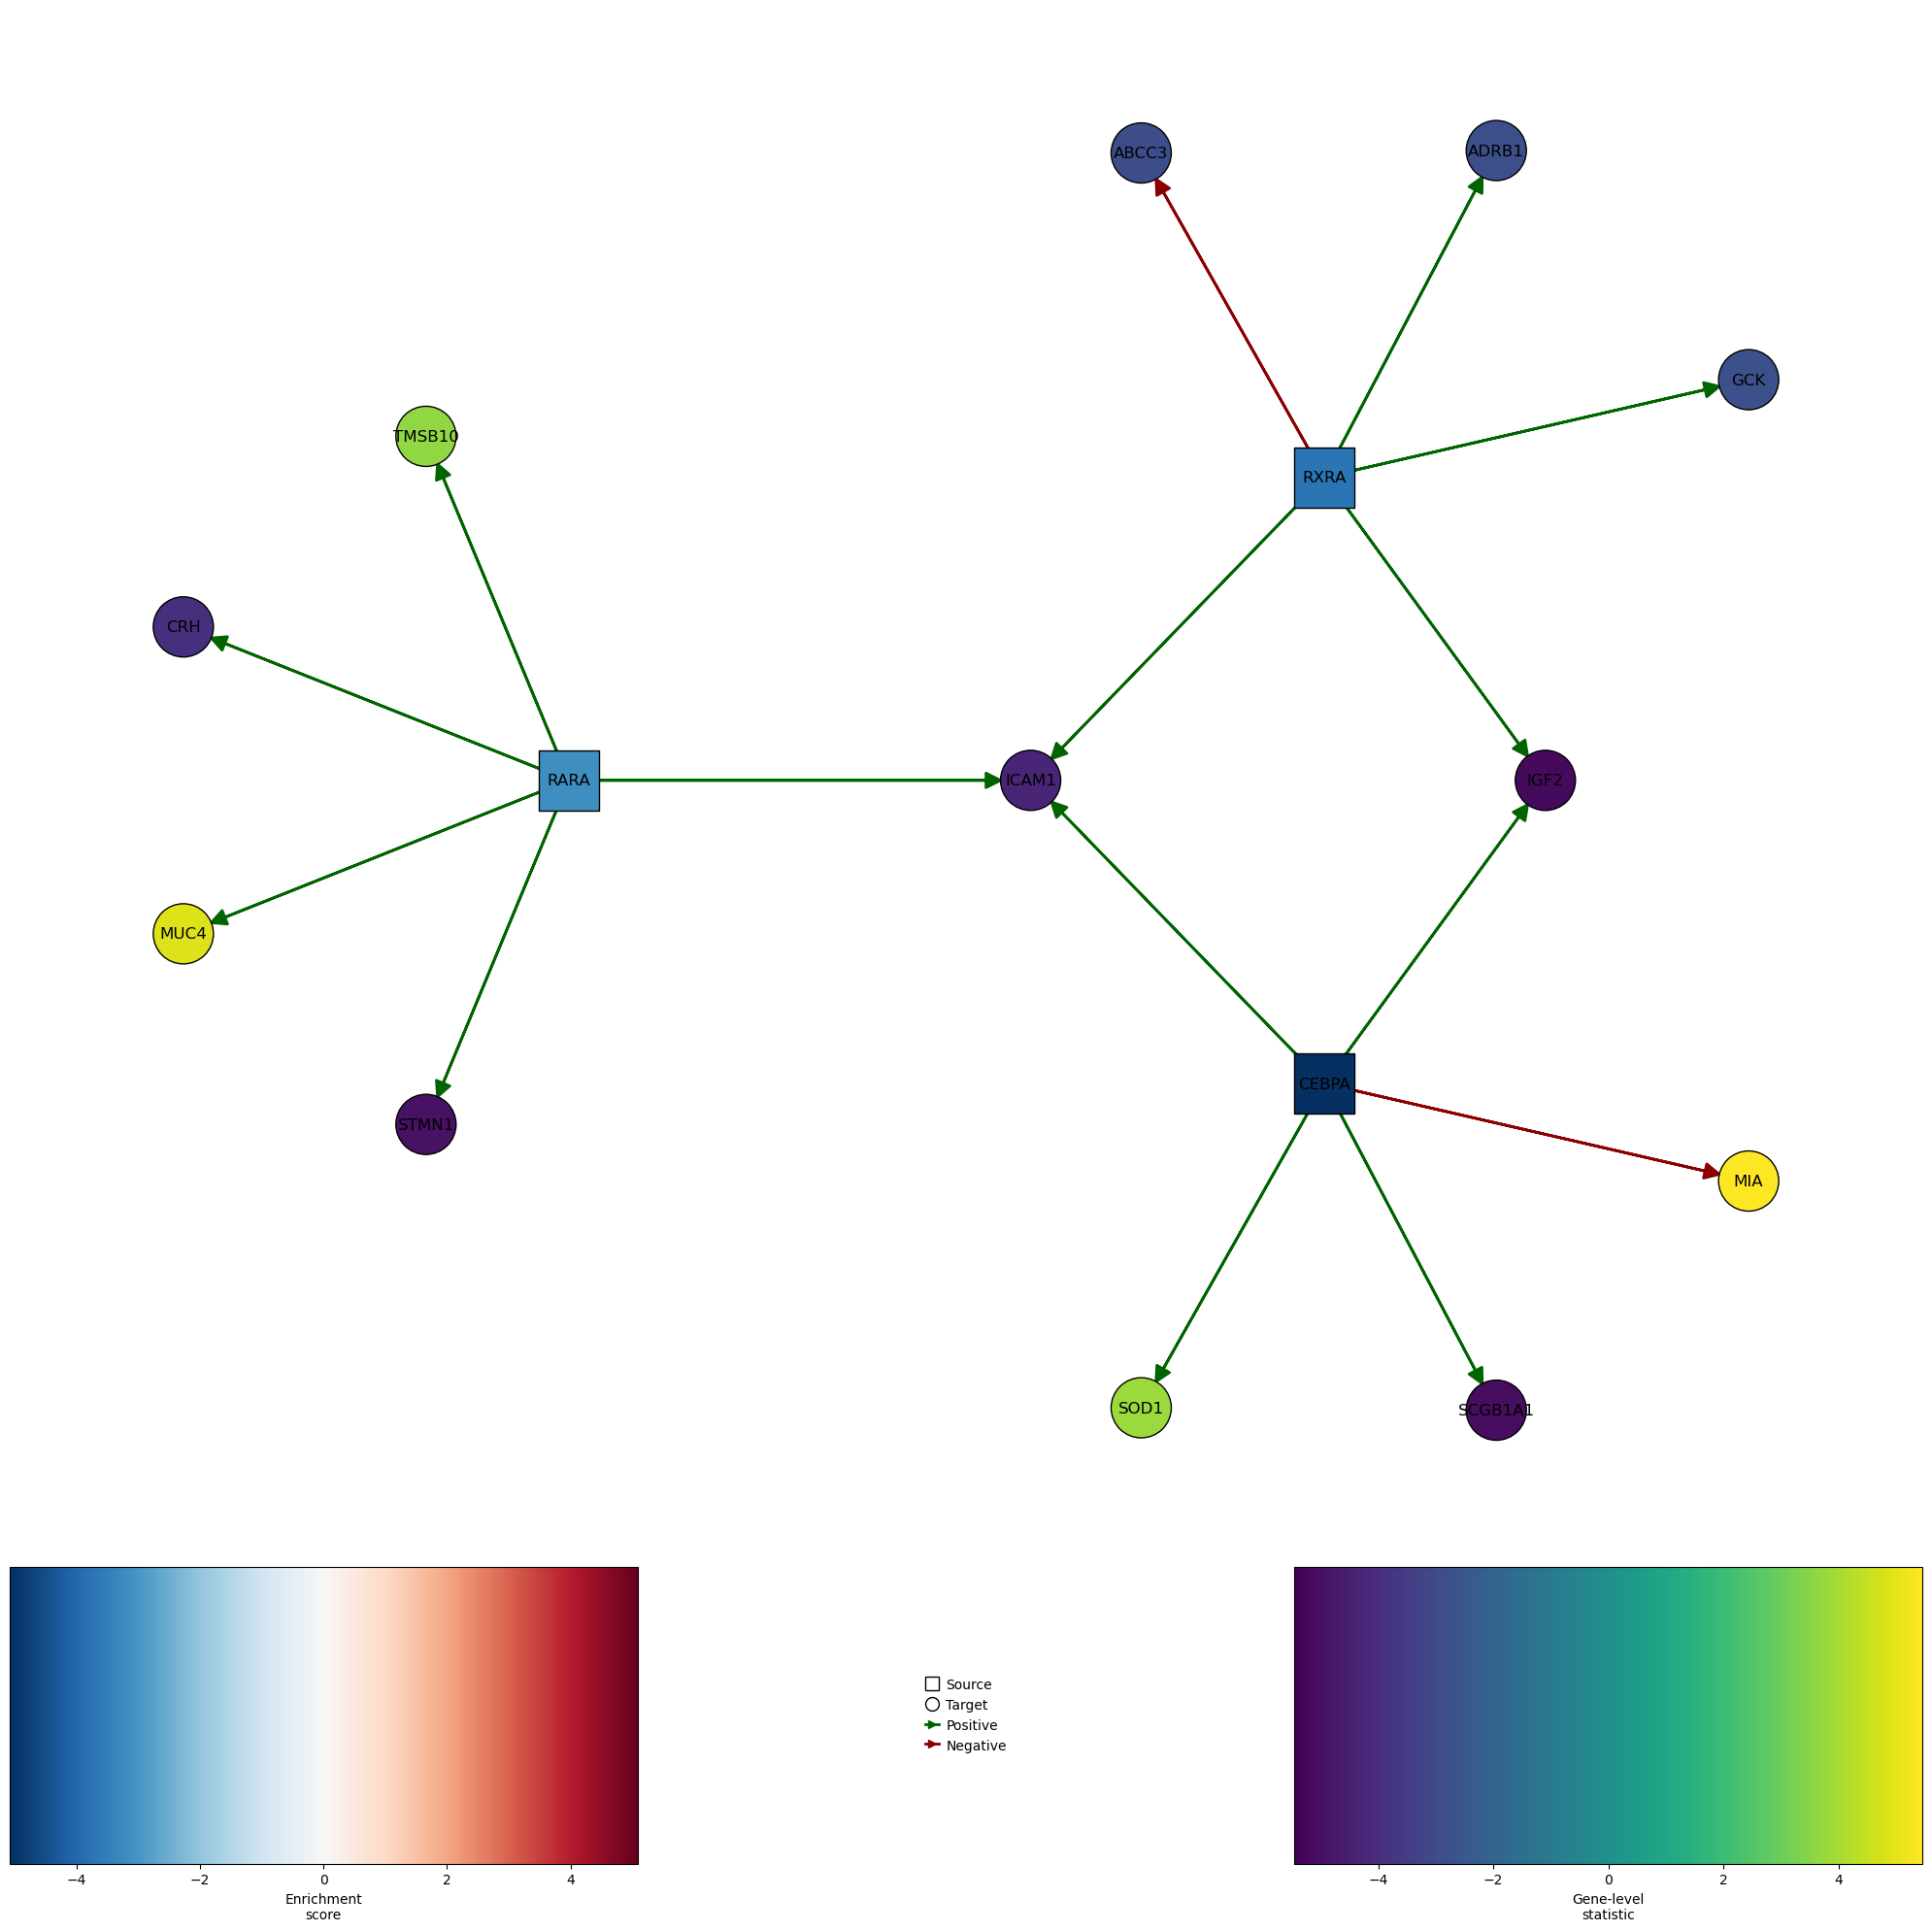

In [21]:
dc.pl.network(
    net=collectri,
    data=data,
    score=tf_acts,
    sources= ["SREBF1", "RXRA", "CEBPA", "RARA"],
    targets=5,
    figsize=(20, 20),
    vcenter=True,
    by_abs=True,
    size_node=250,
    t_label="Gene-level\nstatistic",
)

/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/decoupler/_Plotter.py:37: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  self.fig, self.ax = plt.subplots(1, 1, figsize=self.figsize, dpi=self.dpi, tight_layout=True)


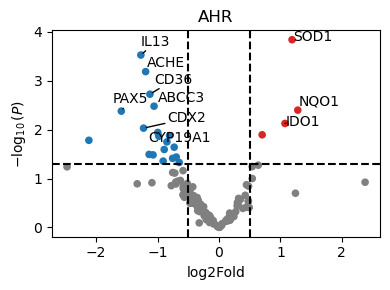

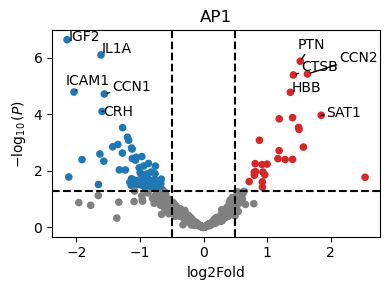

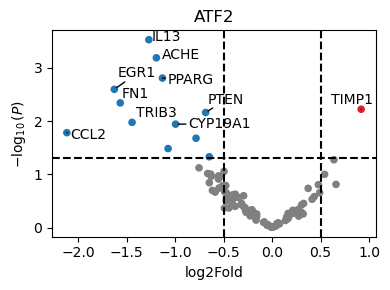

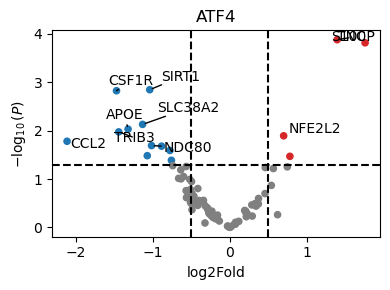

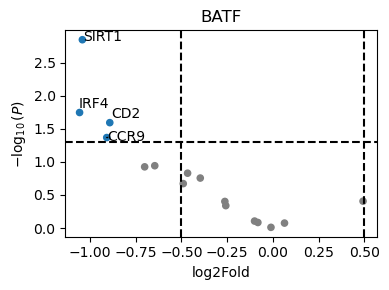

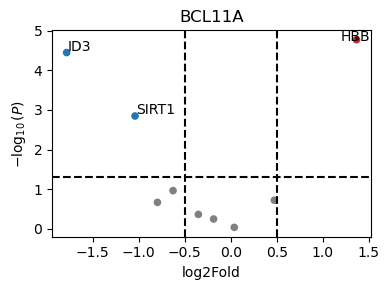

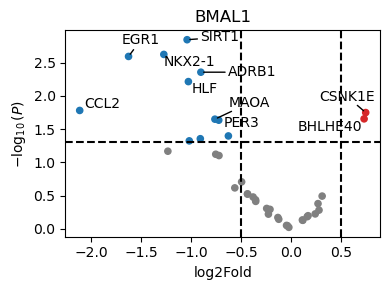

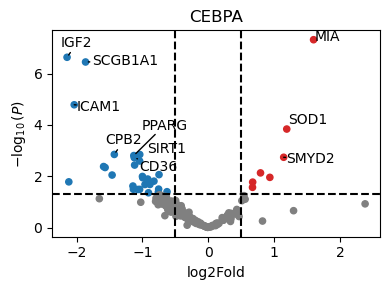

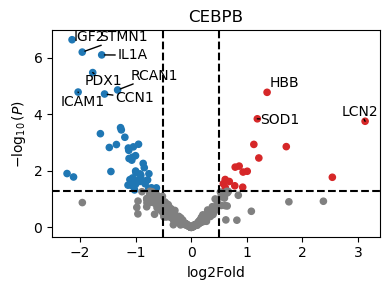

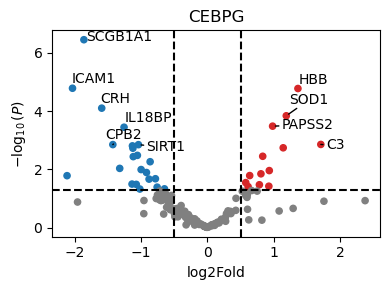

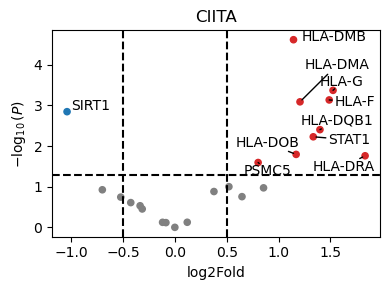

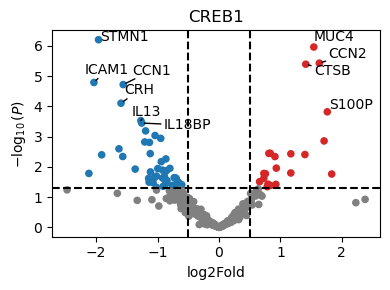

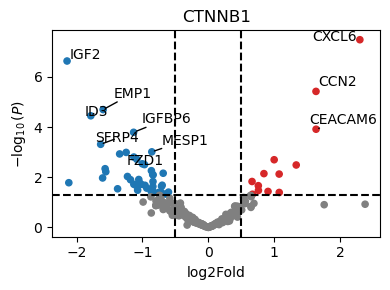

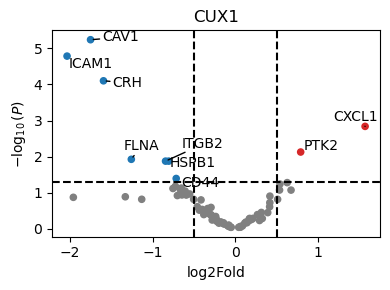

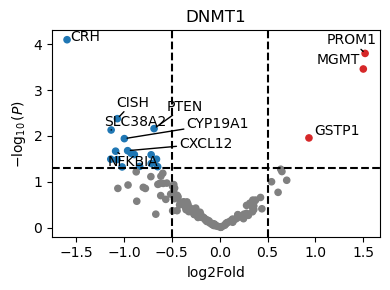

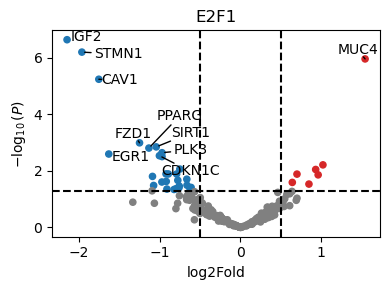

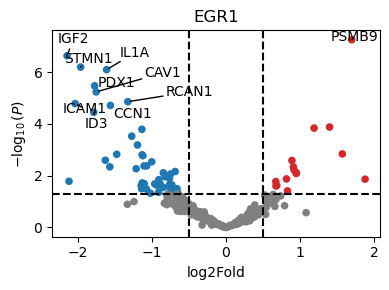

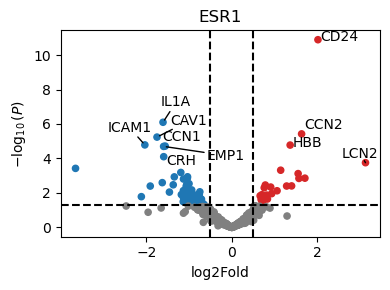

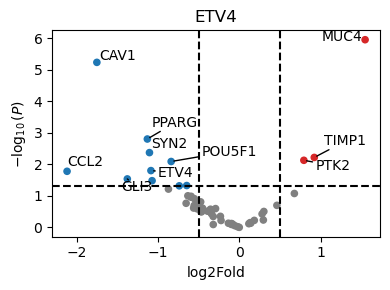

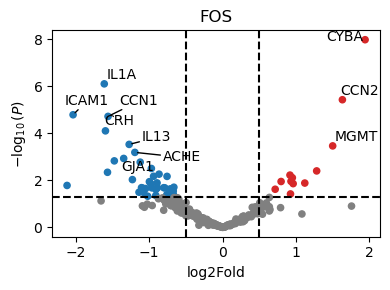

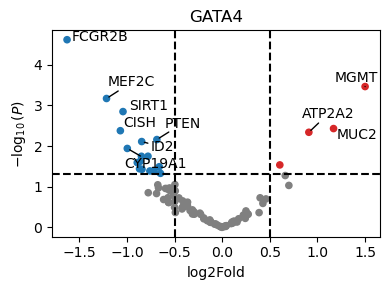

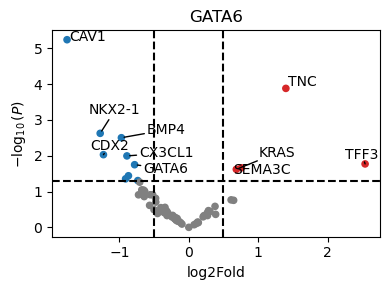

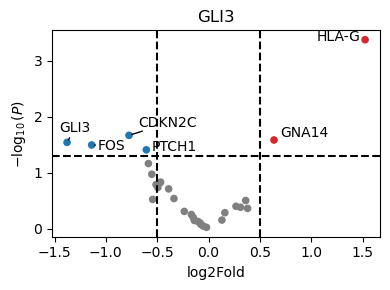

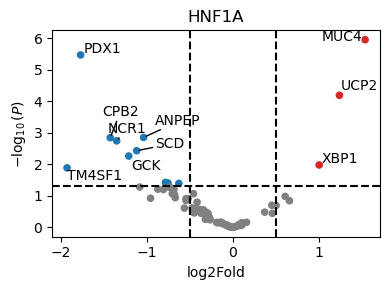

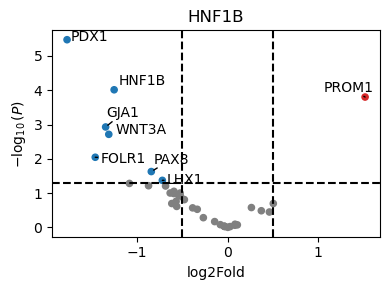

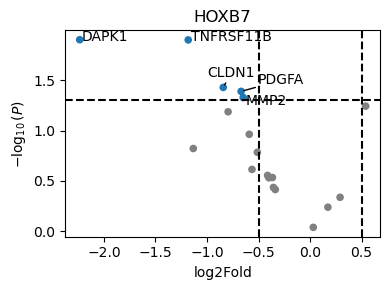

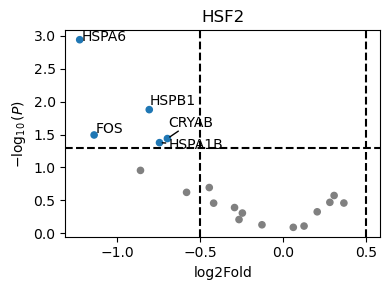

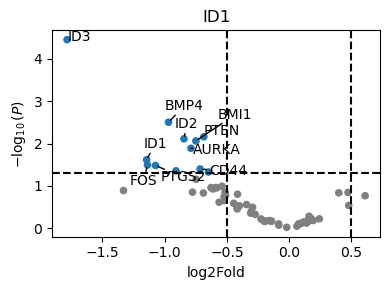

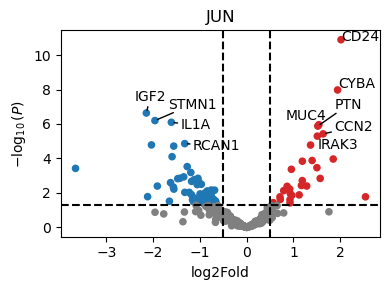

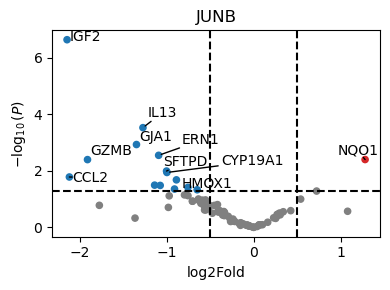

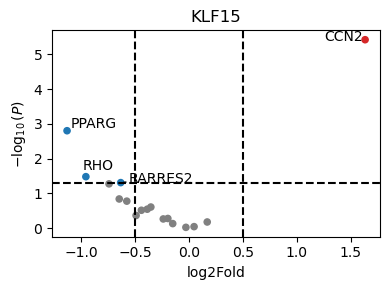

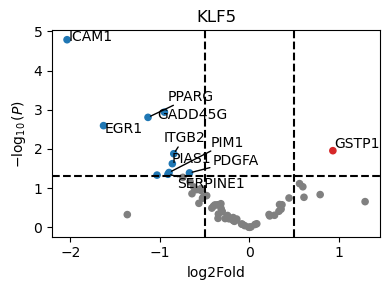

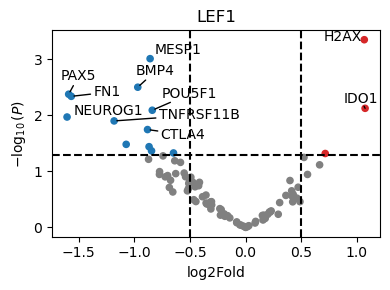

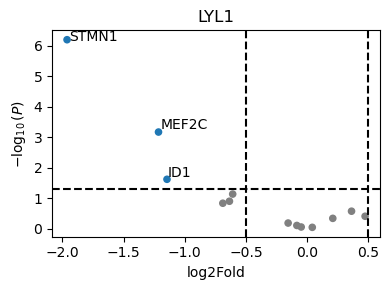

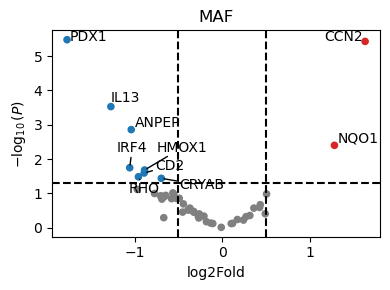

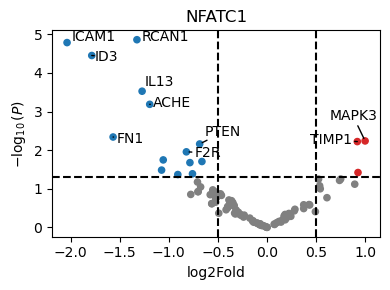

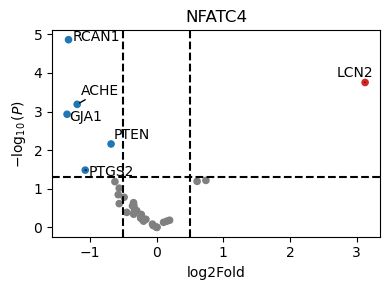

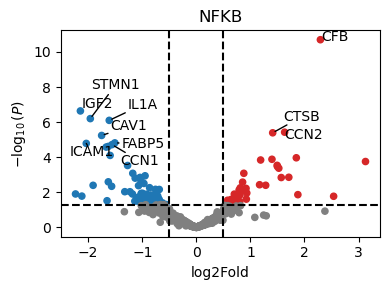

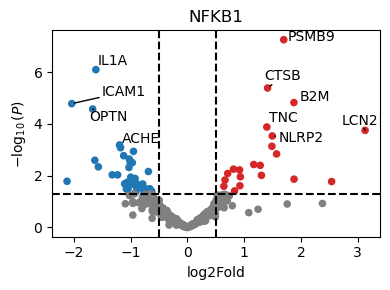

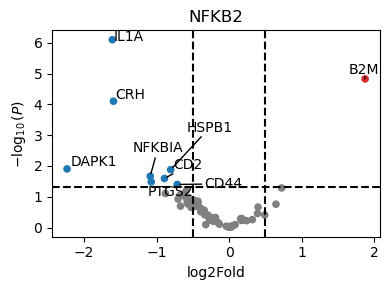

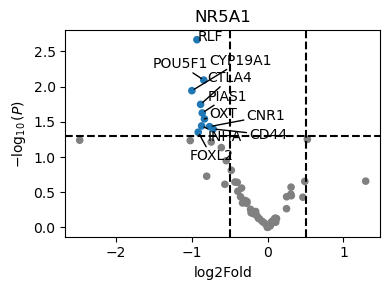

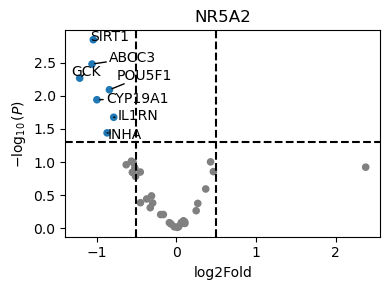

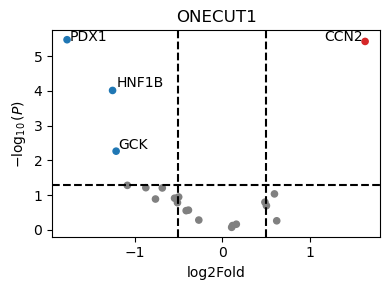

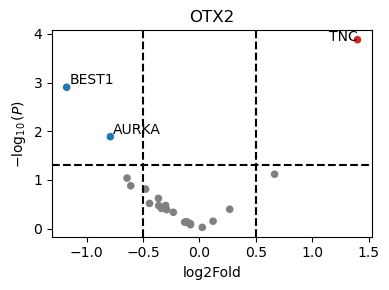

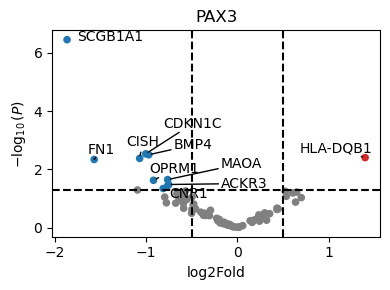

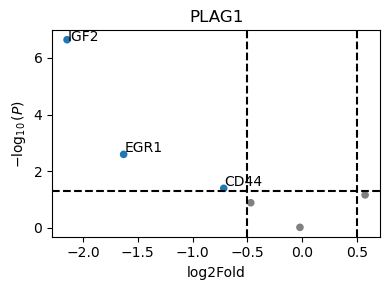

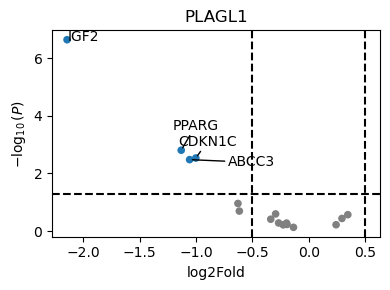

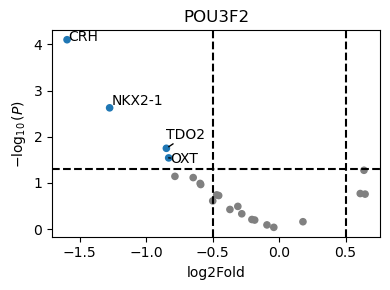

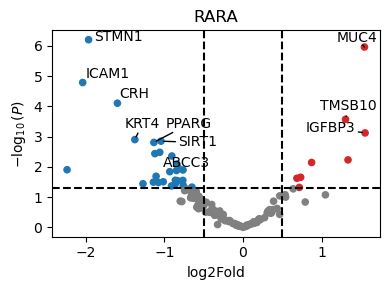

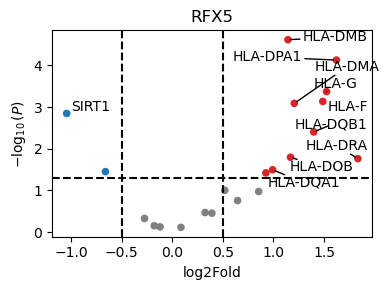

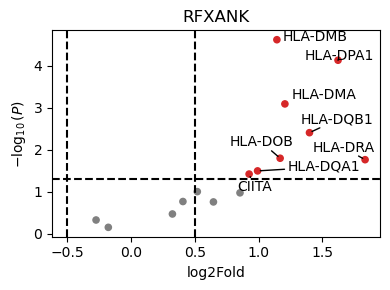

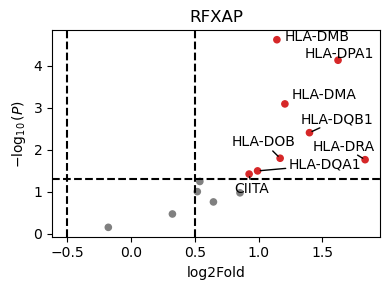

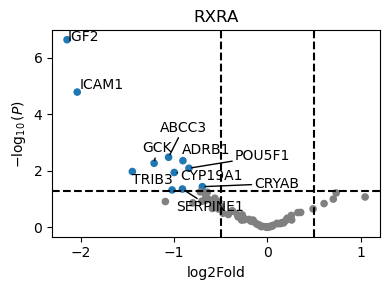

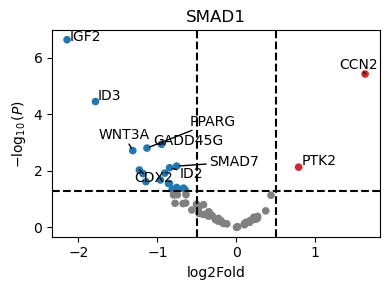

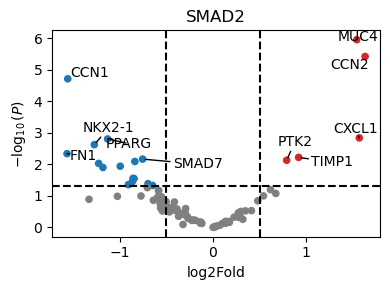

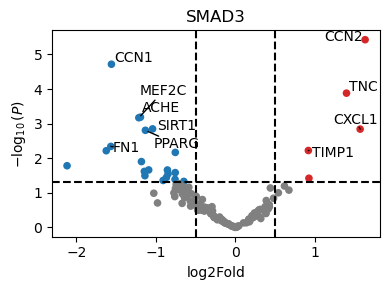

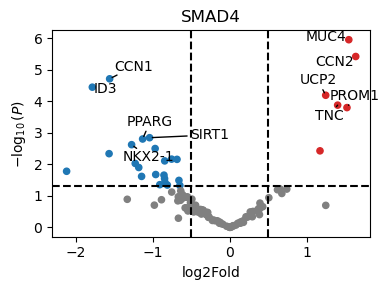

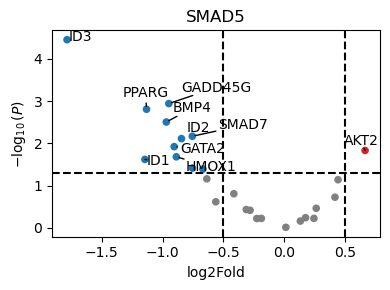

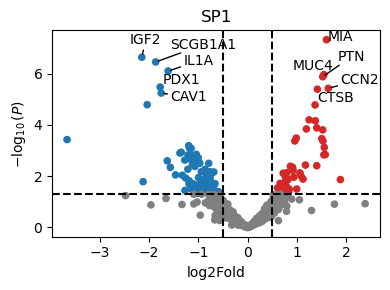

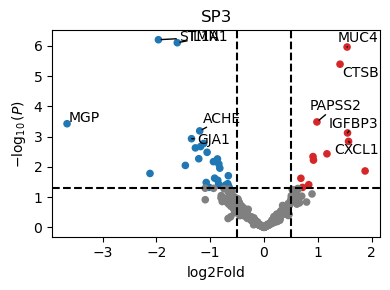

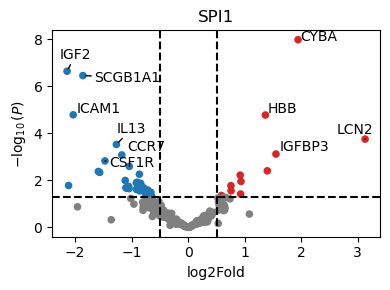

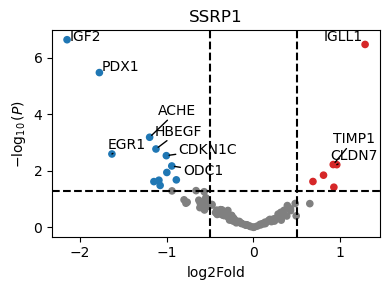

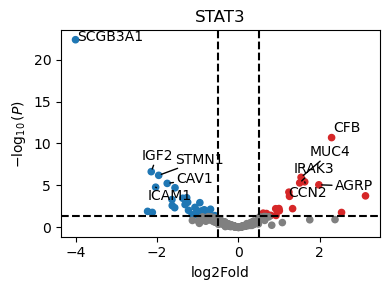

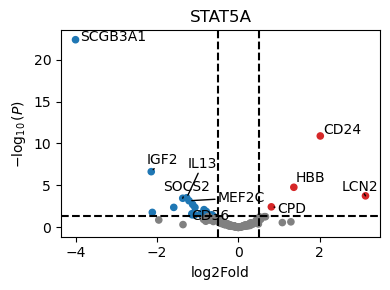

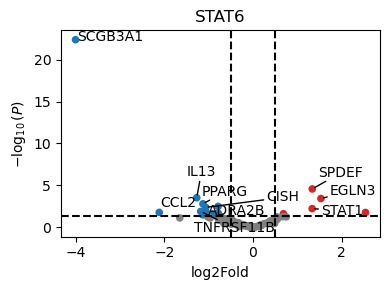

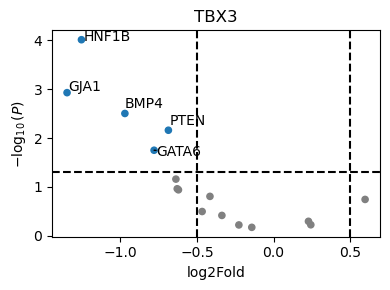

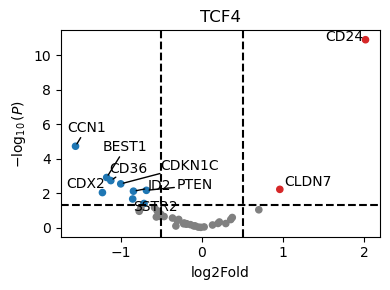

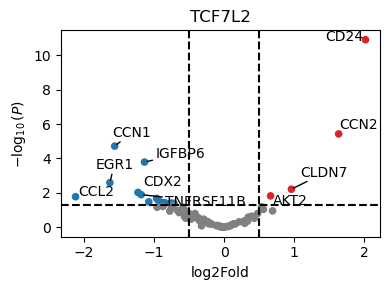

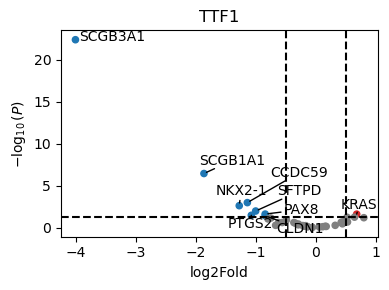

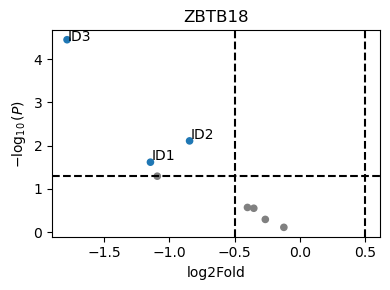

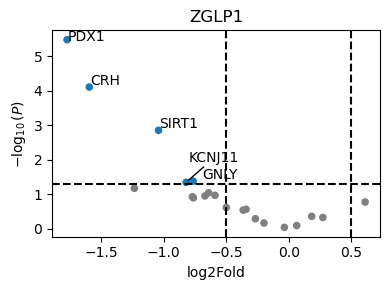

In [22]:
for tf in tfs:

    dc.pl.volcano(
        data=de,
        x="log2Fold",
        y="P",
        net=collectri,
        name=tf,
        top=10,
    )